In [51]:
!pip install polars

In [52]:
import pandas as pd
import polars as pl
import numpy as np
import time

In [53]:
np.random.seed(42)

rows = 1_000_000

data = {
    "station_id": np.random.randint(1, 101, rows),
    "temperature": np.random.uniform(20, 35, rows),
    "salinity": np.random.uniform(0, 35, rows),
    "ph": np.random.uniform(6.5, 9.0, rows),
    "dissolved_oxygen": np.random.uniform(2, 10, rows)
}

df = pd.DataFrame(data)

df.head()

,station_id,temperature,salinity,ph,dissolved_oxygen
0,52,27.647970,20.298693,8.604442,5.912153
1,93,22.914538,24.374776,7.181203,9.318252
2,15,21.350784,18.881543,7.883989,8.690602
3,72,31.284271,25.474341,6.587656,5.860487
4,61,23.235172,28.000423,7.210117,6.568144


In [54]:
df.to_csv("synthetic_water_quality.csv", index=False)

In [55]:
start = time.perf_counter()

pandas_result = (
    df.groupby("station_id")
      .agg({
          "temperature": "mean",
          "salinity": "mean",
          "ph": "mean",
          "dissolved_oxygen": "mean"
      })
)

pandas_time = time.perf_counter() - start

print(f"Pandas execution time: {pandas_time:.4f} seconds")

Pandas execution time: 0.0521 seconds


In [56]:
pl_df = pl.from_pandas(df)

start = time.perf_counter()

polars_result = (
    pl_df.group_by("station_id")
         .agg([
             pl.col("temperature").mean(),
             pl.col("salinity").mean(),
             pl.col("ph").mean(),
             pl.col("dissolved_oxygen").mean()
         ])
)

polars_time = time.perf_counter() - start

print(f"Polars execution time: {polars_time:.4f} seconds")

Polars execution time: 0.0184 seconds


In [57]:
if pandas_time > polars_time:
    speedup = pandas_time / polars_time
    print(f"Polars was approximately {speedup:.2f}x faster than Pandas.")
else:
    speedup = polars_time / pandas_time
    print(f"Pandas was approximately {speedup:.2f}x faster than Polars.")

Polars was approximately 2.84x faster than Pandas.


In [58]:
pl_df = pl.from_pandas(df)

start = time.perf_counter()

polars_result = (
    pl_df.group_by("station_id")
         .agg([
             pl.col("temperature").mean(),
             pl.col("salinity").mean(),
             pl.col("ph").mean(),
             pl.col("dissolved_oxygen").mean()
         ])
)

polars_time = time.perf_counter() - start

print(f"Polars execution time: {polars_time:.4f} seconds")

Polars execution time: 0.0173 seconds


In [59]:
import time
import pandas as pd
import polars as pl

pandas_times = []
polars_times = []

for i in range(20):

    # Pandas
    start = time.perf_counter()

    pandas_result = (
        df.groupby("station_id")
          .agg({
              "temperature": "mean",
              "salinity": "mean",
              "ph": "mean",
              "dissolved_oxygen": "mean"
          })
    )

    pandas_times.append(time.perf_counter() - start)

    # Polars
    start = time.perf_counter()

    polars_result = (
        pl_df.group_by("station_id")
             .agg([
                 pl.col("temperature").mean(),
                 pl.col("salinity").mean(),
                 pl.col("ph").mean(),
                 pl.col("dissolved_oxygen").mean()
             ])
    )

    polars_times.append(time.perf_counter() - start)

print("Pandas runs:", pandas_times)
print("Polars runs:", polars_times)

Pandas runs: [0.05186604699997588, 0.04683018700006869, 0.1065969240000868, 0.08188569899994036, 0.08499051899980259, 0.07910977500000627, 0.05450895500007391, 0.049765548999857856, 0.047732233000033375, 0.04729084499990677, 0.04573001500011742, 0.05097863499986488, 0.0829927019999559, 0.09627247200000966, 0.09080885699995633, 0.08036147400002847, 0.04541764600003262, 0.04635292100010702, 0.0492788289998316, 0.04560598000011851]
Polars runs: [0.017130927999915002, 0.10493248300008418, 0.022690174999979718, 0.03280418800000007, 0.03530386400007046, 0.030889141999978165, 0.018000558000039746, 0.017170406999866827, 0.017307150000078764, 0.017210873000067295, 0.01679096199995911, 0.02938374800010024, 0.03274453600010929, 0.03509121000001869, 0.09498944200004189, 0.01759809000009227, 0.020649943000080384, 0.016812485999935234, 0.01699370699998326, 0.016759587000024112]


In [60]:
import numpy as np

print("Pandas average:", np.mean(pandas_times))
print("Pandas median:", np.median(pandas_times))
print("Pandas std:", np.std(pandas_times))

print()

print("Polars average:", np.mean(polars_times))
print("Polars median:", np.median(polars_times))
print("Polars std:", np.std(polars_times))

Pandas average: 0.06421881319998875
Pandas median: 0.05142234099992038
Pandas std: 0.02022954391711204

Polars average: 0.030562673950021234
Polars median: 0.019325250500060065
Polars std: 0.02417559140371877


In [61]:
benchmark_results = pd.DataFrame({
    "run": range(1, 21),
    "pandas_seconds": pandas_times,
    "polars_seconds": polars_times
})

benchmark_results.to_csv("benchmark_results.csv", index=False)

benchmark_results.head()

,run,pandas_seconds,polars_seconds
0,1,0.051866,0.017131
1,2,0.046830,0.104932
2,3,0.106597,0.022690
3,4,0.081886,0.032804
4,5,0.084991,0.035304


In [62]:
summary_results = pd.DataFrame({
    "library": ["Pandas", "Polars"],
    "average_seconds": [
        np.mean(pandas_times),
        np.mean(polars_times)
    ],
    "median_seconds": [
        np.median(pandas_times),
        np.median(polars_times)
    ],
    "standard_deviation_seconds": [
        np.std(pandas_times),
        np.std(polars_times)
    ]
})

summary_results.to_csv("summary_results.csv", index=False)

summary_results

,library,average_seconds,median_seconds,standard_deviation_seconds
0,Pandas,0.064219,0.051422,0.020230
1,Polars,0.030563,0.019325,0.024176


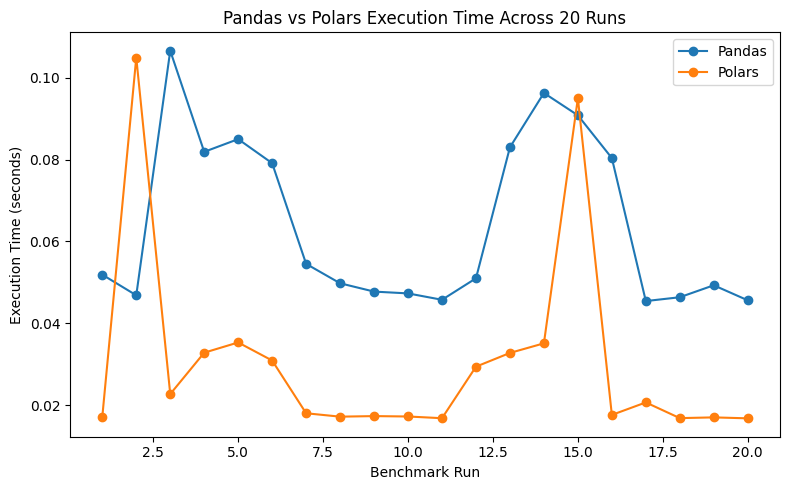

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    benchmark_results["run"],
    benchmark_results["pandas_seconds"],
    marker="o",
    label="Pandas"
)

plt.plot(
    benchmark_results["run"],
    benchmark_results["polars_seconds"],
    marker="o",
    label="Polars"
)

plt.xlabel("Benchmark Run")
plt.ylabel("Execution Time (seconds)")
plt.title("Pandas vs Polars Execution Time Across 20 Runs")
plt.legend()
plt.tight_layout()

plt.savefig(
    "pandas_vs_polars_runs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()